In [1]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd())) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from datetime import datetime, timedelta

from src.constants import hustle_stats, four_factors_stats, home_away_id_cols

pd.set_option('display.max_columns', None)

In [2]:
DATA_DIR = '../data/'
transformed_path = os.path.join(DATA_DIR, 'transformed_data', 'df_transformed.csv')
df_trans = pd.read_csv(transformed_path)

stage1_path = os.path.join(DATA_DIR, 'stage1_effort','df_net_stage1_effort.csv')
df_stage1 = pd.read_csv(stage1_path)

In [3]:
df_trans.head(2)

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_DRtg,EST_AWAY_DRtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256,99.32,102.32,126.862666,114.347146,114.347146,126.862666,12.515520,-12.515520,3,0,7,-4,4,-4,2,3,0,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281,116.12,118.00,105.924905,92.372881,92.372881,105.924905,13.552024,-13.552024,35,4,-8,0,-5,-1,0,-4,1,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035


In [10]:
df_stage1.head(2)

,SEASON_ID,GAME_ID,GAME_DATE,TEAM_ID,TEAM_ABBREVIATION,OFF_COMPOSITE_EFFORT,DEF_COMPOSITE_EFFORT,NET_COMPOSITE_EFFORT
0,22022,22200001,2022-10-18,1610612738,BOS,6.050990,-12.465400,16.712712
1,22022,22200002,2022-10-18,1610612744,GSW,11.661072,-18.468257,26.348261


In [11]:
df_stage1.shape, df_stage1['GAME_ID'].nunique()

((4920, 8), 2460)

In [14]:
df_trans_home_m = df_trans.merge(df_stage1.drop(['SEASON_ID','GAME_DATE','TEAM_ABBREVIATION'],axis=1), how='left', left_on=['GAME_ID','HOME_TEAM_ID'], right_on=['GAME_ID','TEAM_ID'])
df_trans_m = df_trans_home_m.merge(df_stage1.drop(['SEASON_ID','GAME_DATE','TEAM_ABBREVIATION'],axis=1), how='left', left_on=['GAME_ID','AWAY_TEAM_ID'], right_on=['GAME_ID', 'TEAM_ID'], suffixes=('_HOME','_AWAY'))

In [15]:

df_trans_home_m.head(2)

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_DRtg,EST_AWAY_DRtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF,TEAM_ID,OFF_COMPOSITE_EFFORT,DEF_COMPOSITE_EFFORT,NET_COMPOSITE_EFFORT
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256,99.32,102.32,126.862666,114.347146,114.347146,126.862666,12.515520,-12.515520,3,0,7,-4,4,-4,2,3,0,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066,1.610613e+09,6.050990,-12.465400,16.712712
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281,116.12,118.00,105.924905,92.372881,92.372881,105.924905,13.552024,-13.552024,35,4,-8,0,-5,-1,0,-4,1,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035,1.610613e+09,11.661072,-18.468257,26.348261


In [22]:
m_cols_to_keep = home_away_id_cols + ['TEAM_ID_HOME','TEAM_ID_AWAY','OFF_COMPOSITE_EFFORT_HOME','DEF_COMPOSITE_EFFORT_HOME','NET_COMPOSITE_EFFORT_HOME','OFF_COMPOSITE_EFFORT_AWAY','DEF_COMPOSITE_EFFORT_AWAY','NET_COMPOSITE_EFFORT_AWAY']
df_trans_m['TEAM_ID_HOME'] = df_trans_m['TEAM_ID_HOME'].astype(str)
df_trans_m['TEAM_ID_AWAY'] = df_trans_m['TEAM_ID_AWAY'].astype(str)
df_trans_m[m_cols_to_keep].head(2)

,SEASON_ID,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,TEAM_ID_HOME,TEAM_ID_AWAY,OFF_COMPOSITE_EFFORT_HOME,DEF_COMPOSITE_EFFORT_HOME,NET_COMPOSITE_EFFORT_HOME,OFF_COMPOSITE_EFFORT_AWAY,DEF_COMPOSITE_EFFORT_AWAY,NET_COMPOSITE_EFFORT_AWAY
0,22022,22200001,2022-10-18,1610612738,1610612755,BOS,PHI,1610612738.0,1610612755.0,6.050990,-12.465400,16.712712,5.658940,-11.153923,15.098367
1,22022,22200002,2022-10-18,1610612744,1610612747,GSW,LAL,1610612744.0,1610612747.0,11.661072,-18.468257,26.348261,1.602214,-17.934435,19.863003


In [33]:
end_home_cols = df_trans_m.columns[df_trans_m.columns.str.endswith('_HOME')]
end_away_cols = df_trans_m.columns[df_trans_m.columns.str.endswith('_AWAY')]
begin_home_cols = [f"HOME_{col.replace('_HOME','')}" for col in end_home_cols]
begin_away_cols = [f"AWAY_{col.replace('_AWAY','')}" for col in end_away_cols]
home_cols = dict(zip(end_home_cols, begin_home_cols))
away_cols = dict(zip(end_away_cols, begin_away_cols))
new_col_names = {**home_cols, **away_cols}
df_trans_m.rename(columns=new_col_names, inplace=True)

In [34]:
df_trans_m.head()

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_DRtg,EST_AWAY_DRtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF,HOME_TEAM_ID,HOME_OFF_COMPOSITE_EFFORT,HOME_DEF_COMPOSITE_EFFORT,HOME_NET_COMPOSITE_EFFORT,AWAY_TEAM_ID,AWAY_OFF_COMPOSITE_EFFORT,AWAY_DEF_COMPOSITE_EFFORT,AWAY_NET_COMPOSITE_EFFORT
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256,99.32,102.32,126.862666,114.347146,114.347146,126.862666,12.515520,-12.515520,3,0,7,-4,4,-4,2,3,0,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066,1610612738.0,6.050990,-12.465400,16.712712,1610612755.0,5.658940,-11.153923,15.098367
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281,116.12,118.00,105.924905,92.372881,92.372881,105.924905,13.552024,-13.552024,35,4,-8,0,-5,-1,0,-4,1,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035,1610612744.0,11.661072,-18.468257,26.348261,1610612747.0,1.602214,-17.934435,19.863003
2,22022,22200003,2022-10-19,1610612753,1610612765,ORL,DET,Orlando Magic,Detroit Pistons,42,40,86,94,11,14,30,38,14,19,19,24,10,12,38,29,21,31,5,11,5,4,18,13,24,21,109,113,0,10,8,60,59,11,10,12,11,6,4,6,8,26,19,1,4,2,1,26,19,14,12,34,40,5,4,0,0,11,15,0.552,0.500,0.176,0.129,0.221,0.255,0.277,0.293,105.56,102.36,107.048124,106.486909,106.486909,107.048124,0.561215,-0.561215,-7,4,-1,-1,6,-1,0,2,-1,-2,3,-2,-2,-1,-7,-0.052,0.034,-0.047,0.016,1610612765.0,4.710579,-19.989363,23.860860,1610612753.0,6.003612,-15.015829,19.375360
3,22022,22200004,2022-10-19,1610612764,1610612754,WAS,IND,Washington Wizards,Indiana Pacers,42,39,92,97,11,15,31,42,19,14,24,21,14,12,39,30,21,21,5,7,10,5,17,15,19,20,114,107,0,9,8,67,62,13,7,11,5,10,3,5,5,20,17,2,2,2,3,31,21,13,8,36,41,3,3,0,1,14,12,0.516,0.479,0.162,0.144,0.261,0.216,0.353,0.290,109.24,105.56,97.949469,107.995453,107.995453,97.949469,-10.045984,10.045984,-3,-2,-5,-6,5,-6,1,0,1,-5,0,-1,-7,0,-10,-0.037,-0.045,-0.018,-0.063,1610612754.0,5.136641,-15.909757,19.807973,1610612764.0,5.611561,-16.345500,20.547261
4,2202

In [35]:
df_trans_m['NET_COMPOSITE_EFFORT_DIFF'] = df_trans_m['HOME_NET_COMPOSITE_EFFORT']-df_trans_m['AWAY_NET_COMPOSITE_EFFORT']

In [36]:
df_trans_m[['HOME_NET_COMPOSITE_EFFORT','AWAY_NET_COMPOSITE_EFFORT','NET_COMPOSITE_EFFORT_DIFF']].describe()

,HOME_NET_COMPOSITE_EFFORT,AWAY_NET_COMPOSITE_EFFORT,NET_COMPOSITE_EFFORT_DIFF
count,2460.000000,2460.000000,2460.000000
mean,17.628295,17.508771,0.119524
std,3.664548,3.614758,4.630443
min,7.311099,5.756079,-14.773117
25%,14.977595,15.030503,-3.095274
50%,17.531373,17.354840,0.104832
75%,20.060844,19.861641,3.367009
max,33.088875,31.409378,16.561861


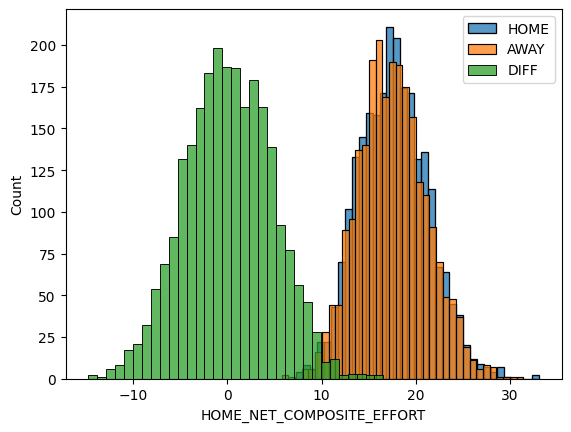

In [41]:
sns.histplot(x='HOME_NET_COMPOSITE_EFFORT', data=df_trans_m, label='HOME')
sns.histplot(x='AWAY_NET_COMPOSITE_EFFORT', data=df_trans_m, label='AWAY')
sns.histplot(x='NET_COMPOSITE_EFFORT_DIFF', data=df_trans_m, label='DIFF')
plt.legend(loc='best')

In [43]:
df_trans_m.drop(['HOME_TEAM_NAME','AWAY_TEAM_NAME'], axis=1, inplace=True)
df_trans_m.rename(columns={'HOME_TEAM_ABBREVIATION':'HOME_TEAM','AWAY_TEAM_ABBREVIATION':'AWAY_TEAM'}, inplace=True)
df_trans_m.head()

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM,HOME_TEAM,AWAY_FGM,HOME_FGM,AWAY_FGA,HOME_FGA,AWAY_FG3M,HOME_FG3M,AWAY_FG3A,HOME_FG3A,AWAY_FTM,HOME_FTM,AWAY_FTA,HOME_FTA,AWAY_OREB,HOME_OREB,AWAY_DREB,HOME_DREB,AWAY_AST,HOME_AST,AWAY_STL,HOME_STL,AWAY_BLK,HOME_BLK,AWAY_TOV,HOME_TOV,AWAY_PF,HOME_PF,AWAY_PTS,HOME_PTS,NEUTRAL_IND,AWAY_SCREEN_ASSISTS,HOME_SCREEN_ASSISTS,AWAY_CONTESTED_SHOTS,HOME_CONTESTED_SHOTS,AWAY_BOX_OUT_PLAYER_TEAM_REBS,HOME_BOX_OUT_PLAYER_TEAM_REBS,AWAY_DEF_BOXOUTS,HOME_DEF_BOXOUTS,AWAY_BOX_OUT_PLAYER_REBS,HOME_BOX_OUT_PLAYER_REBS,AWAY_LOOSE_BALLS_RECOVERED,HOME_LOOSE_BALLS_RECOVERED,AWAY_SCREEN_AST_PTS,HOME_SCREEN_AST_PTS,AWAY_DEF_LOOSE_BALLS_RECOVERED,HOME_DEF_LOOSE_BALLS_RECOVERED,AWAY_OFF_BOXOUTS,HOME_OFF_BOXOUTS,AWAY_CONTESTED_SHOTS_3PT,HOME_CONTESTED_SHOTS_3PT,AWAY_BOX_OUTS,HOME_BOX_OUTS,AWAY_CONTESTED_SHOTS_2PT,HOME_CONTESTED_SHOTS_2PT,AWAY_OFF_LOOSE_BALLS_RECOVERED,HOME_OFF_LOOSE_BALLS_RECOVERED,AWAY_CHARGES_DRAWN,HOME_CHARGES_DRAWN,AWAY_DEFLECTIONS,HOME_DEFLECTIONS,AWAY_EFG_PCT,HOME_EFG_PCT,AWAY_TM_TOV_PCT,HOME_TM_TOV_PCT,AWAY_FTA_RATE,HOME_FTA_RATE,AWAY_OREB_PCT,HOME_OREB_PCT,EST_HOME_POSS,EST_AWAY_POSS,EST_HOME_ORtg,EST_AWAY_ORtg,EST_HOME_DRtg,EST_AWAY_DRtg,EST_HOME_NRtg,EST_AWAY_NRtg,SCREEN_AST_PTS_DIFF,DEFLECTIONS_DIFF,CONTESTED_SHOTS_DIFF,DEF_BOXOUTS_DIFF,CONTESTED_SHOTS_2PT_DIFF,BOX_OUT_PLAYER_TEAM_REBS_DIFF,CHARGES_DRAWN_DIFF,LOOSE_BALLS_RECOVERED_DIFF,OFF_BOXOUTS_DIFF,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF,HOME_TEAM_ID,HOME_OFF_COMPOSITE_EFFORT,HOME_DEF_COMPOSITE_EFFORT,HOME_NET_COMPOSITE_EFFORT,AWAY_TEAM_ID,AWAY_OFF_COMPOSITE_EFFORT,AWAY_DEF_COMPOSITE_EFFORT,AWAY_NET_COMPOSITE_EFFORT,NET_COMPOSITE_EFFORT_DIFF
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,40,46,80,82,13,12,34,35,24,22,28,28,4,6,27,30,16,24,8,8,3,3,14,11,25,24,117,126,0,9,10,27,34,6,2,6,2,4,0,1,4,19,22,1,2,0,0,12,15,6,2,15,19,0,2,0,2,16,16,0.581,0.634,0.143,0.113,0.350,0.341,0.190,0.256,99.32,102.32,126.862666,114.347146,114.347146,126.862666,12.515520,-12.515520,3,0,7,-4,4,-4,2,3,0,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066,1610612738.0,6.050990,-12.465400,16.712712,1610612755.0,5.658940,-11.153923,15.098367,1.614345
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,40,45,94,99,10,16,40,45,19,17,25,23,9,11,39,37,23,31,12,11,4,4,22,18,18,23,109,123,0,3,18,71,63,13,12,11,11,7,6,7,3,8,43,2,2,2,3,36,33,13,14,35,30,5,1,1,1,18,22,0.479,0.535,0.196,0.157,0.266,0.232,0.246,0.281,116.12,118.00,105.924905,92.372881,92.372881,105.924905,13.552024,-13.552024,35,4,-8,0,-5,-1,0,-4,1,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035,1610612744.0,11.661072,-18.468257,26.348261,1610612747.0,1.602214,-17.934435,19.863003,6.485259
2,22022,22200003,2022-10-19,1610612753,1610612765,ORL,DET,42,40,86,94,11,14,30,38,14,19,19,24,10,12,38,29,21,31,5,11,5,4,18,13,24,21,109,113,0,10,8,60,59,11,10,12,11,6,4,6,8,26,19,1,4,2,1,26,19,14,12,34,40,5,4,0,0,11,15,0.552,0.500,0.176,0.129,0.221,0.255,0.277,0.293,105.56,102.36,107.048124,106.486909,106.486909,107.048124,0.561215,-0.561215,-7,4,-1,-1,6,-1,0,2,-1,-2,3,-2,-2,-1,-7,-0.052,0.034,-0.047,0.016,1610612765.0,4.710579,-19.989363,23.860860,1610612753.0,6.003612,-15.015829,19.375360,4.485500
3,22022,22200004,2022-10-19,1610612764,1610612754,WAS,IND,42,39,92,97,11,15,31,42,19,14,24,21,14,12,39,30,21,21,5,7,10,5,17,15,19,20,114,107,0,9,8,67,62,13,7,11,5,10,3,5,5,20,17,2,2,2,3,31,21,13,8,36,41,3,3,0,1,14,12,0.516,0.479,0.162,0.144,0.261,0.216,0.353,0.290,109.24,105.56,97.949469,107.995453,107.995453,97.949469,-10.045984,10.045984,-3,-2,-5,-6,5,-6,1,0,1,-5,0,-1,-7,0,-10,-0.037,-0.045,-0.018,-0.063,1610612754.0,5.136641,-15.909757,19.807973,1610612764.0,5.611561,-16.345500,20.547261,-0.739288
4,22022,22200005,2022-10-19,1610612745,1610612737,HOU,ATL,42,45,98,90,9,7,35,25,14,20,15,24,15,4,39,34,25,30,4,12,3,5,16,9,20,18,107,117,0

In [64]:
df_trans_m['GAME_DATE'] = pd.to_datetime(df_trans_m['GAME_DATE'])
df_train = df_trans_m[df_trans_m['GAME_DATE']< '2024-10-22']
df_train['GAME_DATE'].max(), df_train['GAME_DATE'].min()

(Timestamp('2024-04-14 00:00:00'), Timestamp('2022-10-18 00:00:00'))

In [96]:
cols = ['GAME_ID','HOME_TEAM','AWAY_TEAM','GAME_DATE','HOME_EFG_PCT','AWAY_EFG_PCT', 'HOME_TM_TOV_PCT','AWAY_TM_TOV_PCT','HOME_FTA_RATE','AWAY_FTA_RATE','HOME_OREB_PCT','AWAY_OREB_PCT','HOME_NET_COMPOSITE_EFFORT','AWAY_NET_COMPOSITE_EFFORT']
df_home = (
    df_train[cols]
    .rename(columns={
        'HOME_TEAM':'TEAM',
        'AWAY_TEAM':'OPP_TEAM',
        'HOME_EFG_PCT':'TEAM_EFG_PCT',
        'AWAY_EFG_PCT':'OPP_EFG_PCT',
        'HOME_TM_TOV_PCT': 'TEAM_TOV_PCT',
        'AWAY_TM_TOV_PCT':'OPP_TOV_PCT',
        'HOME_FTA_RATE':'TEAM_FTA_RATE',
        'AWAY_FTA_RATE':'OPP_FTA_RATE',
        'HOME_OREB_PCT':'TEAM_OREB_PCT',
        'AWAY_OREB_PCT':'OPP_OREB_PCT',
        'HOME_NET_COMPOSITE_EFFORT':'TEAM_NET_COMPOSITE_EFFORT',
        'AWAY_NET_COMPOSITE_EFFORT':'OPP_NET_COMPOSITE_EFFORT'
    })
    .assign(HOME_IND=1)
)
df_away = (
    df_train[cols]
    .rename(columns={
        'AWAY_TEAM':'TEAM',
        'HOME_TEAM':'OPP_TEAM',
        'HOME_EFG_PCT':'OPP_EFG_PCT',
        'AWAY_EFG_PCT':'TEAM_EFG_PCT',
        'HOME_TM_TOV_PCT': 'OPP_TOV_PCT',
        'AWAY_TM_TOV_PCT':'TEAM_TOV_PCT',
        'HOME_FTA_RATE':'OPP_FTA_RATE',
        'AWAY_FTA_RATE':'TEAM_FTA_RATE',
        'HOME_OREB_PCT':'OPP_OREB_PCT',
        'AWAY_OREB_PCT':'TEAM_OREB_PCT',
        'HOME_NET_COMPOSITE_EFFORT':'OPP_NET_COMPOSITE_EFFORT',
        'AWAY_NET_COMPOSITE_EFFORT':'TEAM_NET_COMPOSITE_EFFORT'
    })
    .assign(HOME_IND=0)
)
team_schedule = (
    pd.concat([df_home, df_away], ignore_index=True)
    .sort_values(['TEAM','GAME_DATE'])
    .reset_index(drop=True)
)

# Create team win column
#team_schedule['TEAM_WIN'] = (team_schedule['TEAM_PTS']>team_schedule['OPP_PTS']).astype(int)

# Create season for grouping
team_schedule['GAME_ID_str'] = team_schedule['GAME_ID'].astype(str)
team_schedule['SEASON_SUFFIX'] = team_schedule['GAME_ID_str'].str[1:3]
team_schedule['SEASON'] = '20' + team_schedule['SEASON_SUFFIX']
team_schedule['SEASON'] = team_schedule['SEASON'].astype(int)
team_schedule.drop(['GAME_ID_str','SEASON_SUFFIX'], axis=1, inplace=True)
team_schedule.drop(['OPP_EFG_PCT','OPP_TOV_PCT','OPP_FTA_RATE','OPP_OREB_PCT','OPP_NET_COMPOSITE_EFFORT'], axis=1, inplace=True)

In [97]:
team_schedule.head(20)

,GAME_ID,TEAM,OPP_TEAM,GAME_DATE,TEAM_EFG_PCT,TEAM_TOV_PCT,TEAM_FTA_RATE,TEAM_OREB_PCT,TEAM_NET_COMPOSITE_EFFORT,HOME_IND,SEASON
0,22200005,ATL,HOU,2022-10-19,0.539,0.085,0.267,0.128,25.511594,1,2022
1,22200020,ATL,ORL,2022-10-21,0.522,0.167,0.180,0.286,17.615417,1,2022
2,22200038,ATL,CHA,2022-10-23,0.453,0.119,0.295,0.333,19.932250,1,2022
3,22200057,ATL,DET,2022-10-26,0.538,0.120,0.275,0.333,20.317339,0,2022
4,22200070,ATL,DET,2022-10-28,0.629,0.071,0.186,0.333,22.063370,0,2022
5,22200085,ATL,MIL,2022-10-29,0.548,0.129,0.160,0.294,24.224276,0,2022
6,22200099,ATL,TOR,2022-10-31,0.530,0.175,0.298,0.255,13.814541,0,2022
7,22200110,ATL,NYK,2022-11-02,0.467,0.089,0.150,0.364,16.005865,0,2022
8,22200134,ATL,NOP,2022-11-05,0.500,0.114,0.243,0.276,26.250382,1,2022
9,22200149,ATL,MIL,2022-11-07,0.520,0.117,0.172,0.321,27.972887,1,2022


In [128]:
four_factors_stats

['EFG_PCT', 'FTA_RATE', 'TM_TOV_PCT', 'OREB_PCT']

In [119]:
team_schedule.groupby('TEAM')['TEAM_NET_COMPOSITE_EFFORT'].ewm(alpha=.9)

ExponentialMovingWindowGroupby [alpha=0.9,min_periods=1,adjust=True,ignore_na=False,axis=0,method=single]

In [125]:
team_schedule['LAG1_EFFORT'] = team_schedule.groupby('TEAM')['TEAM_NET_COMPOSITE_EFFORT'].shift(1).reset_index(drop=True)
team_schedule['MOV_AVG_EFFORT'] = team_schedule.groupby('TEAM')['TEAM_NET_COMPOSITE_EFFORT'].rolling(window=10, min_periods=1,closed='left').mean().reset_index(drop=True)
team_schedule['EWM_AVG_EFFORT'] = team_schedule.groupby('TEAM')['TEAM_NET_COMPOSITE_EFFORT'].ewm(alpha=.9).mean().reset_index(drop=True)

In [126]:
team_schedule.head(10)

,GAME_ID,TEAM,OPP_TEAM,GAME_DATE,TEAM_EFG_PCT,TEAM_TOV_PCT,TEAM_FTA_RATE,TEAM_OREB_PCT,TEAM_NET_COMPOSITE_EFFORT,HOME_IND,SEASON,LAG1_EFFORT,MOV_AVG_EFFORT,EWM_AVG_EFFORT
0,22200005,ATL,HOU,2022-10-19,0.539,0.085,0.267,0.128,25.511594,1,2022,NaN,NaN,25.511594
1,22200020,ATL,ORL,2022-10-21,0.522,0.167,0.180,0.286,17.615417,1,2022,25.511594,25.511594,18.333252
2,22200038,ATL,CHA,2022-10-23,0.453,0.119,0.295,0.333,19.932250,1,2022,17.615417,21.563506,19.773791
3,22200057,ATL,DET,2022-10-26,0.538,0.120,0.275,0.333,20.317339,0,2022,19.932250,21.019754,20.263033
4,22200070,ATL,DET,2022-10-28,0.629,0.071,0.186,0.333,22.063370,0,2022,20.317339,20.844150,21.883353
5,22200085,ATL,MIL,2022-10-29,0.548,0.129,0.160,0.294,24.224276,0,2022,22.063370,21.087994,23.990186
6,22200099,ATL,TOR,2022-10-31,0.530,0.175,0.298,0.255,13.814541,0,2022,24.224276,21.610708,14.832104
7,22200110,ATL,NYK,2022-11-02,0.467,0.089,0.150,0.364,16.005865,0,2022,13.814541,20.496970,15.888489
8,22200134,ATL,NOP,2022-11-05,0.500,0.114,0.243,0.276,26.250382,1,2022,16.005865,19.935582,25.214192
9,22200149,ATL,MIL,2022-11-07,0.520,0.117,0.172,0.321,27.972887,1,2022,26.250382,20.637226,27.697018


In [127]:
team_schedule.tail(10)

,GAME_ID,TEAM,OPP_TEAM,GAME_DATE,TEAM_EFG_PCT,TEAM_TOV_PCT,TEAM_FTA_RATE,TEAM_OREB_PCT,TEAM_NET_COMPOSITE_EFFORT,HOME_IND,SEASON,LAG1_EFFORT,MOV_AVG_EFFORT,EWM_AVG_EFFORT
4910,22301050,WAS,BKN,2024-03-27,0.582,0.133,0.187,0.229,17.009949,1,2023,11.092949,15.567062,16.489560
4911,22301065,WAS,DET,2024-03-29,0.460,0.188,0.091,0.231,16.725658,1,2023,17.009949,15.907531,16.702049
4912,22301081,WAS,MIA,2024-03-31,0.517,0.154,0.239,0.265,9.862809,1,2023,16.725658,16.385503,10.546733
4913,22301095,WAS,MIL,2024-04-02,0.554,0.105,0.183,0.170,17.487460,1,2023,9.862809,15.804236,16.793388
4914,22301103,WAS,LAL,2024-04-03,0.593,0.165,0.143,0.149,22.811498,1,2023,17.487460,15.992135,22.209687
4915,22301117,WAS,POR,2024-04-05,0.460,0.103,0.341,0.255,19.732018,1,2023,22.811498,16.331678,19.979785
4916,22301137,WAS,TOR,2024-04-07,0.562,0.138,0.337,0.176,14.656352,0,2023,19.732018,16.500283,15.188695
4917,22301152,WAS,MIN,2024-04-09,0.607,0.130,0.191,0.234,16.566963,0,2023,14.656352,16.309910,16.429136
4918,22301172,WAS,CHI,2024-04-12,0.628,0.114,0.337,0.128,17.856567,1,2023,16.566963,16.449136,17.713824
4919,22301186,WAS,BOS,2024-04-14,0.544,0.114,0.097,0.259,11.245528,0,2023,17.856567,16.380222,11.892358


In [80]:
team_schedule.head()

,GAME_ID,TEAM,OPP_TEAM,GAME_DATE,TEAM_PTS,OPP_PTS,HOME_IND,TEAM_WIN,SEASON,GAME_ID_str,SEASON_SUFFIX
0,22200005,ATL,HOU,2022-10-19,117,107,1,1,2022,22200005,22
1,22200020,ATL,ORL,2022-10-21,108,98,1,1,2022,22200020,22
2,22200038,ATL,CHA,2022-10-23,109,126,1,0,2022,22200038,22
3,22200057,ATL,DET,2022-10-26,118,113,0,1,2022,22200057,22
4,22200070,ATL,DET,2022-10-28,136,112,0,1,2022,22200070,22


In [81]:
team_schedule.tail()

,GAME_ID,TEAM,OPP_TEAM,GAME_DATE,TEAM_PTS,OPP_PTS,HOME_IND,TEAM_WIN,SEASON,GAME_ID_str,SEASON_SUFFIX
4915,22301117,WAS,POR,2024-04-05,102,108,1,0,2023,22301117,23
4916,22301137,WAS,TOR,2024-04-07,122,130,0,0,2023,22301137,23
4917,22301152,WAS,MIN,2024-04-09,121,130,0,0,2023,22301152,23
4918,22301172,WAS,CHI,2024-04-12,127,129,1,0,2023,22301172,23
4919,22301186,WAS,BOS,2024-04-14,122,132,0,0,2023,22301186,23


In [57]:
df_away.query("TEAM=='ATL'").head()

,GAME_ID,OPP_TEAM,TEAM,GAME_DATE,OPP_TEAM_PTS,TEAM_PTS,HOME_IND
56,22200057,DET,ATL,2022-10-26,113,118,0
69,22200070,DET,ATL,2022-10-28,112,136,0
84,22200085,MIL,ATL,2022-10-29,123,115,0
98,22200099,TOR,ATL,2022-10-31,139,109,0
109,22200110,NYK,ATL,2022-11-02,99,112,0


In [49]:
df_away.head()

,GAME_ID,OPP_TEAM,TEAM,GAME_DATE,OPP_TEAM_PTS,TEAM_PTS,HOME_IND
0,22200001,BOS,PHI,2022-10-18,126,117,0
1,22200002,GSW,LAL,2022-10-18,123,109,0
2,22200003,DET,ORL,2022-10-19,113,109,0
3,22200004,IND,WAS,2022-10-19,107,114,0
4,22200005,ATL,HOU,2022-10-19,117,107,0


In [ ]:
# Predict home net rating from info prior to game start
def team_schedule(
    df: pd.DataFrame, 
    date_col: str = 'game_date', 
) -> pd.DataFrame:
     
    """
    Transform a games DataFrame into a team-centric schedule view.
    
    Takes a DataFrame with game data (home_team vs away_team format) and converts it
    into a schedule where each row represents one team's game, with an indicator
    for whether they played at home or away.
    
    Args:
        df (pd.DataFrame): DataFrame containing game data with columns:
        date_col (str, optional): Name of the date column. Defaults to 'game_date'.
        date_time_col (str, optional): Name of the datetime column. Defaults to 'game_date_time'.
    
    Returns:
        DataFrame containing scoring, home indicator, and win columns.
            
        The DataFrame is sorted by team name and then by game datetime.
     """
    # Extract home and away games for every team
    cols = ['home_team','away_team', date_col, 'home_score','away_score']
    home_schedule = (
        df[cols]
        .rename(columns={
            'home_team': 'team',
            'away_team': 'opp_team',
            'home_score': 'team_score',
            'away_score': 'opp_score'
        })
        .assign(home_ind=1)
    )
    away_schedule = (
        df[cols]
        .rename(columns={
            'away_team': 'team',
            'home_team': 'opp_team',
            'home_score': 'opp_score',
            'away_score': 'team_score'
        })
        .assign(home_ind=0)
    )

    # Join them into one 'team' column
    team_schedule = (
        pd.concat([home_schedule, away_schedule])
        .sort_values(['team',date_time_col])
        .reset_index(drop=True)
    )

    # Create team win column
    team_schedule['team_win'] = (team_schedule['team_score'] > team_schedule['opp_score']).astype(int)

    # Create run differential column (team_score - opp_score)
    team_schedule['team_run_diff'] = team_schedule['team_score'] - team_schedule['opp_score']

    # Create season for grouping
    team_schedule['season'] = team_schedule['game_date'].dt.year.astype('int64')

    # Create flag for first game of season
    team_schedule['team_season_opener_flag'] = (team_schedule.groupby(['team','season']).cumcount()==0).astype(int)

    return team_schedule